In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
df = pd.read_csv("loan_approval_data.csv")
df.shape

(1000, 20)

In [3]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Handling missing data

In [5]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64","int64"]).columns

In [6]:
from sklearn.impute import SimpleImputer
cat_imp = SimpleImputer(strategy = "most_frequent")
num_imp = SimpleImputer(strategy = "mean")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])
df.isnull().sum().sum()

0

# EDA

In [8]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


Text(0.5, 1.0, 'Loan Approval data')

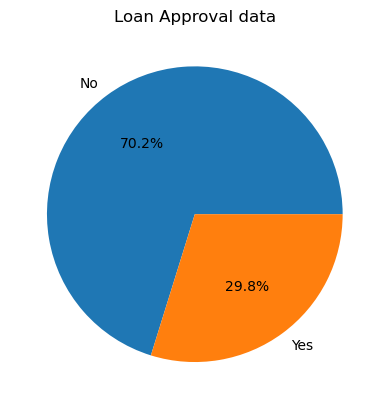

In [9]:
class_counts = df["Loan_Approved"].value_counts()
plt.pie(class_counts,labels=["No", "Yes"],autopct = "%1.1f%%")
plt.title("Loan Approval data")

<Axes: xlabel='Gender', ylabel='count'>

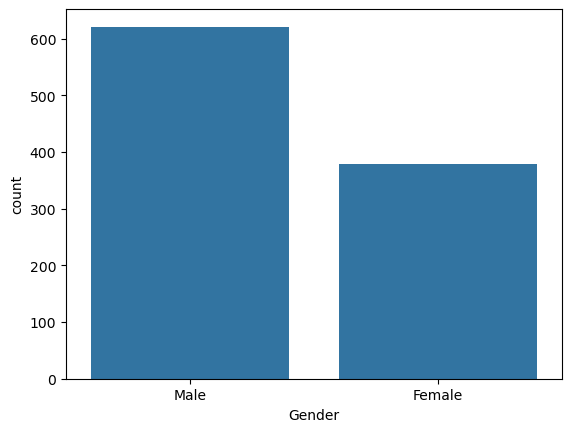

In [10]:
import seaborn as sns
gender_cnt = df["Gender"].value_counts()
sns.barplot(gender_cnt)

<Axes: xlabel='Education_Level', ylabel='count'>

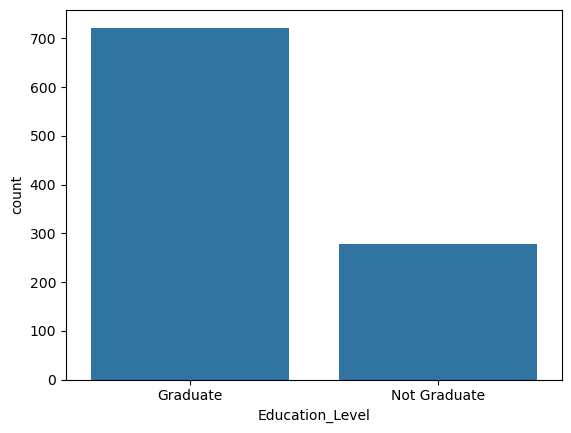

In [11]:
education_cnt = df["Education_Level"].value_counts()
sns.barplot(education_cnt)

<Axes: xlabel='Employment_Status', ylabel='count'>

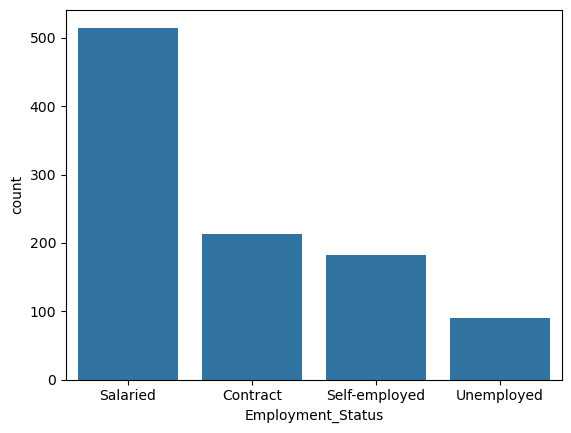

In [12]:
employment_cnt = df["Employment_Status"].value_counts()
sns.barplot(employment_cnt)

<Axes: xlabel='Marital_Status', ylabel='count'>

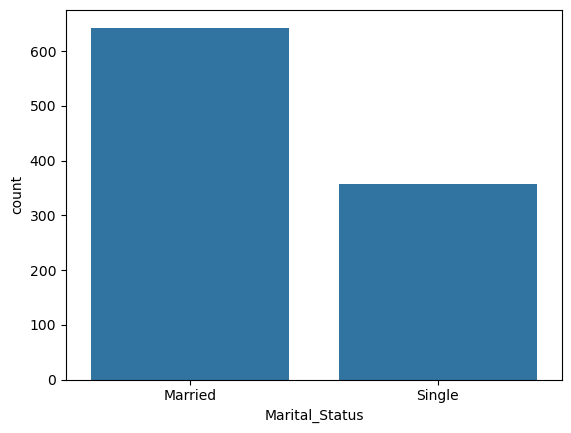

In [13]:
marr_cnt = df["Marital_Status"].value_counts()
sns.barplot(marr_cnt)

<Axes: xlabel='Loan_Purpose', ylabel='count'>

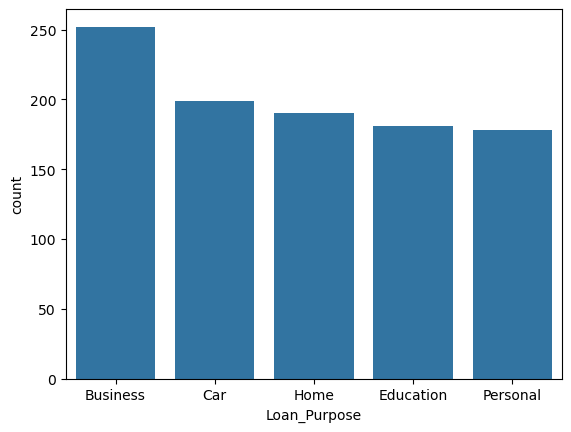

In [14]:
count = df["Loan_Purpose"].value_counts()
sns.barplot(count)

<Axes: xlabel='Property_Area', ylabel='count'>

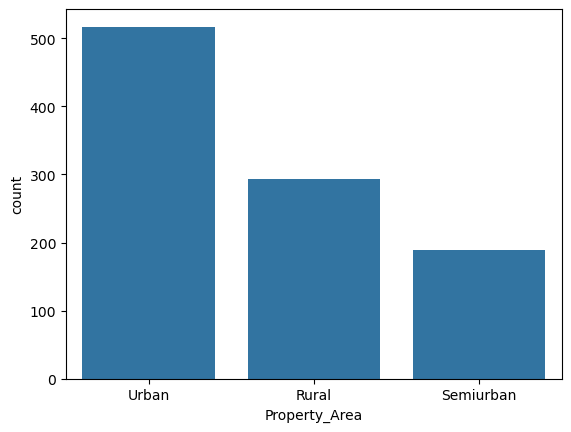

In [15]:
count = df["Property_Area"].value_counts()
sns.barplot(count)

<Axes: xlabel='Employer_Category', ylabel='count'>

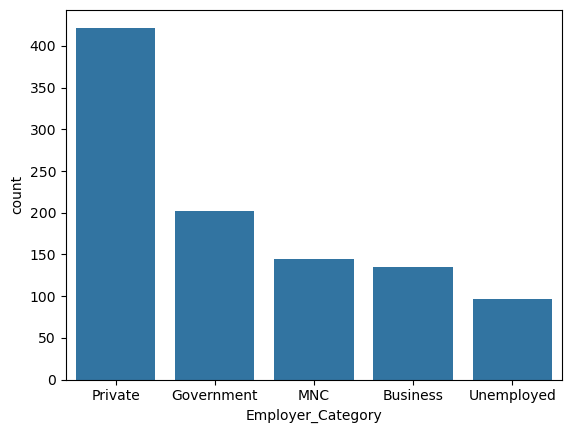

In [16]:
count = df["Employer_Category"].value_counts()
sns.barplot(count)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

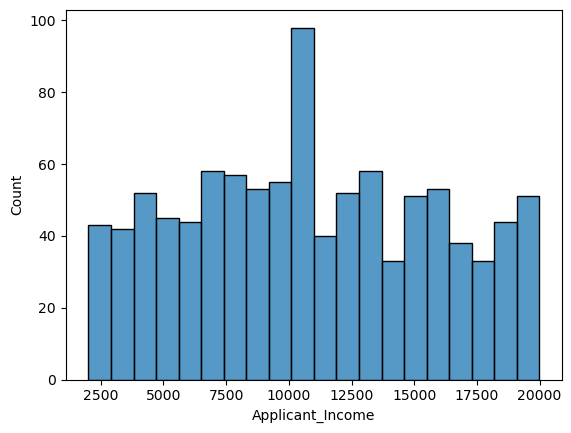

In [17]:
sns.histplot(
    data=df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

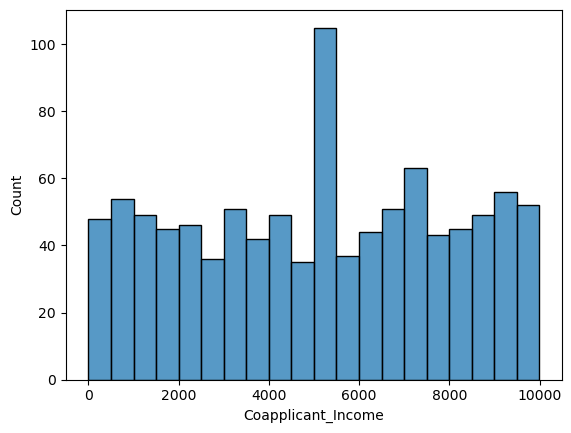

In [18]:

sns.histplot(
    data=df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

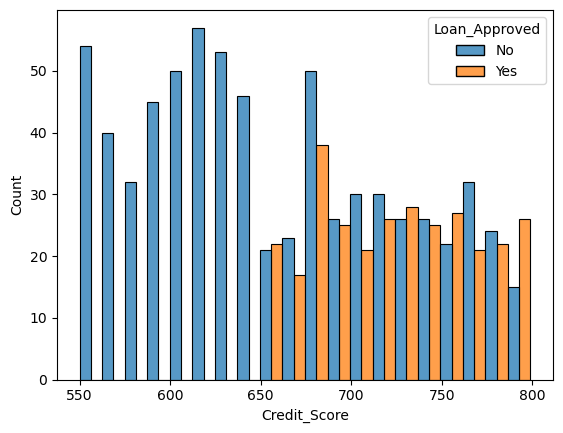

In [19]:
# Credit score vs Loan approval

sns.histplot(
    data=df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins=20,
    multiple = "dodge"
)

Minimum Credit score criteria = 650

In [21]:
df = df.drop("Applicant_ID", axis=1)
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [22]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [23]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [24]:
cols = categorical_cols.drop(["Education_Level", "Loan_Approved"])
cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Gender', 'Employer_Category'],
      dtype='object')

In [25]:
ohe = OneHotEncoder(drop = "first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
df_encoded = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index = df.index)

In [26]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Employment_Status_Salaried       1000 non-null   float64
 1   Employment_Status_Self-employed  1000 non-null   float64
 2   Employment_Status_Unemployed     1000 non-null   float64
 3   Marital_Status_Single            1000 non-null   float64
 4   Loan_Purpose_Car                 1000 non-null   float64
 5   Loan_Purpose_Education           1000 non-null   float64
 6   Loan_Purpose_Home                1000 non-null   float64
 7   Loan_Purpose_Personal            1000 non-null   float64
 8   Property_Area_Semiurban          1000 non-null   float64
 9   Property_Area_Urban              1000 non-null   float64
 10  Gender_Male                      1000 non-null   float64
 11  Employer_Category_Government     1000 non-null   float64
 12  Employer_Category_MNC

In [27]:
df_new = pd.concat([df.drop(cols,axis=1), df_encoded], axis=1,)
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int32  
 12  Loan_Approved        

# Correlation Heatmap

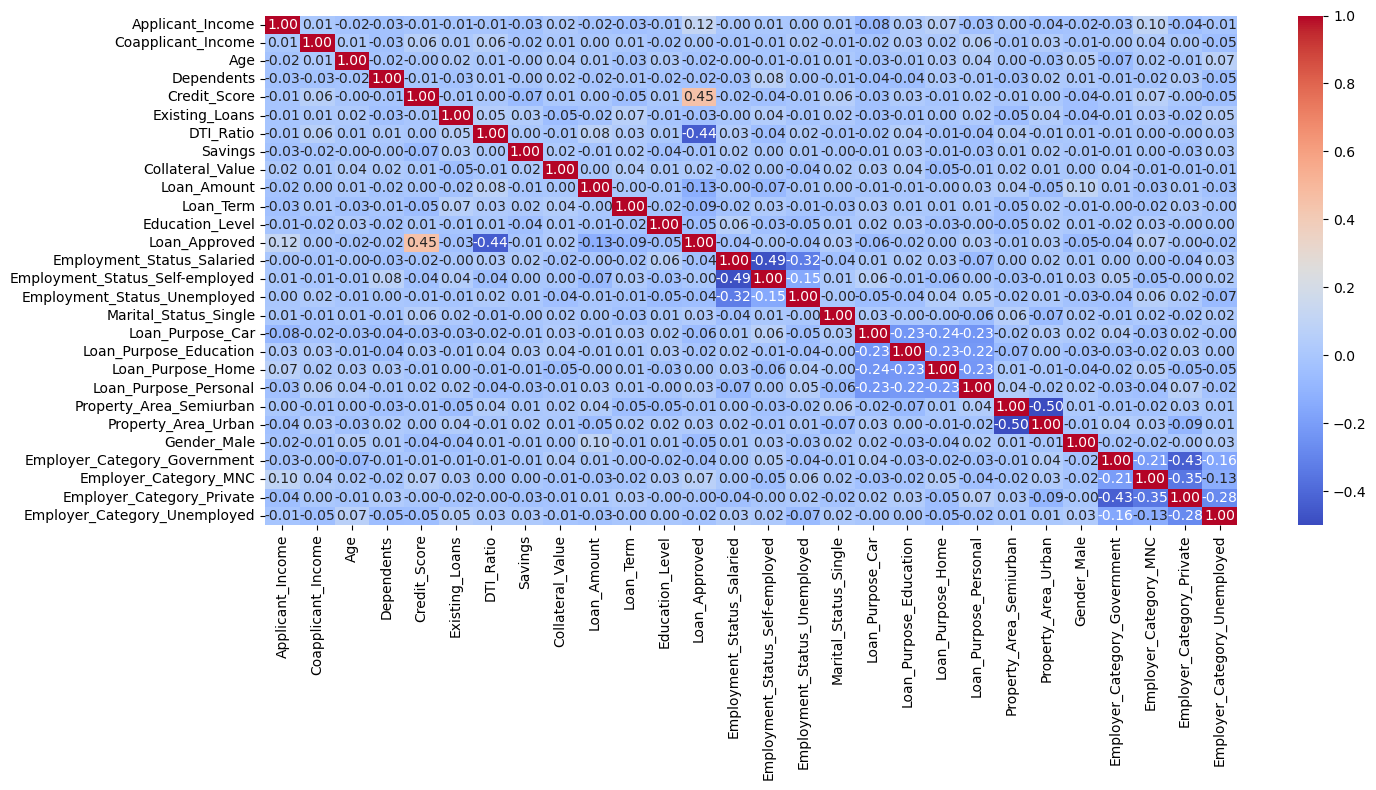

In [29]:
all_cols = df_new.select_dtypes(include = "number")
corr_matrix = all_cols.corr()
plt.figure(figsize = (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)
plt.tight_layout()
plt.show()

Data is Non-linear

# Model Training

In [32]:
X = df_new.drop("Loan_Approved", axis = 1)
y = df_new["Loan_Approved"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Since we need False Positive value for our Problem Statement so Precision score is useful

In [35]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("Precison score for Logistic Regression =", precision_score(y_test, y_pred_lr))
print(classification_report(y_test,y_pred_lr))

Precison score for Logistic Regression = 0.7833333333333333
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       139
           1       0.78      0.77      0.78        61

    accuracy                           0.86       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.86      0.86      0.86       200



In [36]:
# KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("Precison score for KNeighborsClassifier =", precision_score(y_test, y_pred_knn))
print(classification_report(y_test,y_pred_knn))

Precison score for KNeighborsClassifier = 0.6274509803921569
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       139
           1       0.63      0.52      0.57        61

    accuracy                           0.76       200
   macro avg       0.72      0.69      0.70       200
weighted avg       0.75      0.76      0.75       200



In [37]:
# Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)
print("Precison score for Naive Bayes =", precision_score(y_test, y_pred_nb))
print(classification_report(y_test,y_pred_nb))

Precison score for Naive Bayes = 0.8035714285714286
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       139
           1       0.80      0.74      0.77        61

    accuracy                           0.86       200
   macro avg       0.85      0.83      0.84       200
weighted avg       0.86      0.86      0.86       200



In [38]:
# DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)
y_pred_clf = clf.predict(X_test_scaled)
print("Precison score for DecisionTreeClassifier =", precision_score(y_test, y_pred_clf))
print(classification_report(y_test,y_pred_clf))

Precison score for DecisionTreeClassifier = 0.8360655737704918
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       139
           1       0.84      0.84      0.84        61

    accuracy                           0.90       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.90      0.90      0.90       200



In [39]:
# RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rfc.fit(X_train_scaled, y_train)
y_pred_rfc = rfc.predict(X_test_scaled)
print("Precison score for RandomForestClassifier =", precision_score(y_test, y_pred_rfc))
print(classification_report(y_test,y_pred_rfc))

Precison score for RandomForestClassifier = 0.8387096774193549
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       139
           1       0.84      0.85      0.85        61

    accuracy                           0.91       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.91      0.91      0.91       200



In [40]:
# GradientBoostingClassifier
gbc = GradientBoostingClassifier(learning_rate=0.1, n_estimators=100, subsample=1.0, random_state=42)
gbc.fit(X_train_scaled, y_train)
y_pred_gbc = gbc.predict(X_test_scaled)
print("Precison score for GradientBoostingClassifier =", precision_score(y_test, y_pred_gbc))
print(classification_report(y_test,y_pred_gbc))

Precison score for GradientBoostingClassifier = 0.8333333333333334
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       139
           1       0.83      0.90      0.87        61

    accuracy                           0.92       200
   macro avg       0.89      0.91      0.90       200
weighted avg       0.92      0.92      0.92       200



# Best model based on precison score : Random Forest

In [42]:
# Feature engineering
df_new.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [82]:
df_new["Credit_Score_sq"] = df_new["Credit_Score"] ** 2

X = df_new.drop(["Loan_Approved", "Credit_Score"], axis = 1)
y = df_new["Loan_Approved"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rfc.fit(X_train_scaled, y_train)
y_pred_rfc = rfc.predict(X_test_scaled)
print("Precison score for RandomForestClassifier =", precision_score(y_test, y_pred_rfc))
print(classification_report(y_test,y_pred_rfc))

Precison score for RandomForestClassifier = 0.8412698412698413
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       139
           1       0.84      0.87      0.85        61

    accuracy                           0.91       200
   macro avg       0.89      0.90      0.89       200
weighted avg       0.91      0.91      0.91       200

